In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
from src.stats import compare_groups, compare_groups_by_event

In [3]:
df = pd.read_csv("mapper_df.csv", index_col = 0)

In [4]:
df.head()

,thread_id,label,event,n_tweets,n_nodes_mapper,n_edges_mapper,h0_mapper,h1_mapper
0,498235547685756928,non-rumour,ferguson,15,8,1,7,0
1,498248415223246848,non-rumour,ferguson,27,8,4,5,1
2,498248648699150336,non-rumour,ferguson,57,12,6,7,1
3,498250100079341568,non-rumour,ferguson,5,4,0,4,0
4,498251940997136384,non-rumour,ferguson,9,5,1,4,0


### Significance tests

In [5]:
significance_results_by_label = compare_groups(
    df,
    label_col = "label",
    feature_cols = ["h1_mapper", "h0_mapper"],
    group_a = "rumour",
    group_b = "non-rumour",
)

significance_results_by_label

,feature,rumour_n,non-rumour_n,rumour_mean,non-rumour_mean,rumour_median,non-rumour_median,u_stat,p_value,p_value_fdr,significant_fdr_0.05
0,h1_mapper,1972,3830,0.292596,0.415927,0.0,0.0,3635823.0,0.000140,0.000280,True
1,h0_mapper,1972,3830,5.210953,5.490339,5.0,5.0,3564233.0,0.000401,0.000401,True


Mapper-based topological summaries show statistically significant differences between rumours and non-rumours for both h1_mapper and h0_mapper. In both cases, non-rumours exhibit slightly higher average values.

In [6]:
significance_results_by_event = compare_groups_by_event(
    df,
    event_col = "event",
    label_col = "label",
    feature_cols = ["h1_mapper", "h0_mapper"],
    group_a = "rumour",
    group_b = "non-rumour",
)

significance_results_by_event

,event,feature,rumour_n,non-rumour_n,rumour_mean,non-rumour_mean,rumour_median,non-rumour_median,u_stat,p_value,p_value_fdr,significant_fdr_0.05
0,charliehebdo,h1_mapper,458,1621,0.275109,0.405305,0.0,0.0,351151.0,0.004952,0.004952,True
1,charliehebdo,h0_mapper,458,1621,5.200873,5.650216,5.0,5.0,337227.5,0.002496,0.004952,True
2,ferguson,h1_mapper,284,859,0.626761,0.491269,0.0,0.0,124166.0,0.492969,0.492969,False
3,ferguson,h0_mapper,284,859,6.105634,5.782305,6.0,6.0,131166.5,0.055016,0.110032,False
4,germanwings-crash,h1_mapper,238,231,0.176471,0.056277,0.0,0.0,28872.5,0.041075,0.082150,False
5,germanwings-crash,h0_mapper,238,231,4.004202,3.852814,4.0,3.0,27927.0,0.762536,0.762536,False
6,ottawashooting,h1_mapper,470,420,0.138298,0.247619,0.0,0.0,98350.0,0.841797,0.841797,False
7,ottawashooting,h0_mapper,470,420,5.014894,4.850000,5.0,4.5,103586.5,0.196334,0.392668,False
8,sydneysiege,h1_mapper,522,699,0.318008,0.567954,0.0,0.0,171440.0,0.006225,0.012450,True
9,sydneysiege,h0_mapper,522,699,5.459770,5.686695,5.0,5.0,174942.5,0.214416,0.214416,False


Event-level analysis shows that Mapper-based topological summaries are informative only in some contexts. In particular, h1_mapper is significantly different between rumours and non-rumours in charliehebdo and sydneysiege, while h0_mapper is significant only in charliehebdo. In these significant cases, non-rumours exhibit slightly higher Mapper-based topological values than rumours.

In [7]:
df.groupby("event")[["n_tweets", "h0_mapper", "h1_mapper"]].corr(method="spearman")

n_tweets  h0_mapper  h1_mapper
event                                                      
charliehebdo      n_tweets   1.000000   0.769166   0.500992
                  h0_mapper  0.769166   1.000000   0.420685
                  h1_mapper  0.500992   0.420685   1.000000
ferguson          n_tweets   1.000000   0.785749   0.544096
                  h0_mapper  0.785749   1.000000   0.432664
                  h1_mapper  0.544096   0.432664   1.000000
germanwings-crash n_tweets   1.000000   0.895942   0.398533
                  h0_mapper  0.895942   1.000000   0.343714
                  h1_mapper  0.398533   0.343714   1.000000
ottawashooting    n_tweets   1.000000   0.761800   0.381010
                  h0_mapper  0.761800   1.000000   0.327710
                  h1_mapper  0.381010   0.327710   1.000000
sydneysiege       n_tweets   1.000000   0.723244   0.513863
                  h0_mapper  0.723244   1.000000   0.402537
                  h1_mapper  0.513863   0.402537   1.000000

Across all events, h0_mapper has a high Spearman correlation with n_tweets, so the more tweets a thread has, the larger and more topologically complex the Mapper graph tends to be. That means a lot of the Mapper signal may simply reflect thread size, not a distinct structural property of rumours.

### Significance tests after normalization on thread size

In [8]:
df["h0_mapper_per_tweet"] = df["h0_mapper"] / df["n_tweets"]
df["h1_mapper_per_tweet"] = df["h1_mapper"] / df["n_tweets"]

In [9]:
significance_results_by_label = compare_groups(
    df,
    label_col = "label",
    feature_cols = ["h0_mapper_per_tweet", "h1_mapper_per_tweet"],
    group_a = "rumour",
    group_b = "non-rumour",
)

significance_results_by_label

,feature,rumour_n,non-rumour_n,rumour_mean,non-rumour_mean,rumour_median,non-rumour_median,u_stat,p_value,p_value_fdr,significant_fdr_0.05
0,h0_mapper_per_tweet,1972,3830,0.452951,0.417965,0.388889,0.357143,4066618.0,0.000002,0.000003,True
1,h1_mapper_per_tweet,1972,3830,0.007869,0.009931,0.000000,0.000000,3644273.5,0.000347,0.000347,True


In [10]:
significance_results_by_event = compare_groups_by_event(
    df,
    event_col = "event",
    label_col = "label",
    feature_cols = ["h0_mapper_per_tweet", "h1_mapper_per_tweet"],
    group_a = "rumour",
    group_b = "non-rumour",
)

significance_results_by_event

,event,feature,rumour_n,non-rumour_n,rumour_mean,non-rumour_mean,rumour_median,non-rumour_median,u_stat,p_value,p_value_fdr,significant_fdr_0.05
0,charliehebdo,h0_mapper_per_tweet,458,1621,0.471586,0.413433,0.400000,0.350000,418787.0,0.000027,0.000054,True
1,charliehebdo,h1_mapper_per_tweet,458,1621,0.007555,0.010624,0.000000,0.000000,351470.0,0.005716,0.005716,True
2,ferguson,h0_mapper_per_tweet,284,859,0.368471,0.393587,0.348913,0.363636,115952.0,0.211045,0.422089,False
3,ferguson,h1_mapper_per_tweet,284,859,0.011518,0.010351,0.000000,0.000000,124171.5,0.492232,0.492232,False
4,germanwings-crash,h0_mapper_per_tweet,238,231,0.514256,0.558340,0.458042,0.545455,25336.5,0.138417,0.138417,False
5,germanwings-crash,h1_mapper_per_tweet,238,231,0.007012,0.002848,0.000000,0.000000,28831.5,0.047555,0.095110,False
6,ottawashooting,h0_mapper_per_tweet,470,420,0.489614,0.483323,0.421053,0.410428,101134.5,0.524354,0.841601,False
7,ottawashooting,h1_mapper_per_tweet,470,420,0.004348,0.006213,0.000000,0.000000,98349.5,0.841601,0.841601,False
8,sydneysiege,h0_mapper_per_tweet,522,699,0.421602,0.372772,0.368421,0.315789,208660.5,0.000017,0.000034,True
9,sydneysiege,h1_mapper_per_tweet,522,699,0.009720,0.012383,0.000000,0.000000,172935.0,0.018176,0.018176,True


After normalizing Mapper features by thread length, statistically significant differences remain in charliehebdo and sydneysiege. In both events, rumours have higher h0_mapper_per_tweet, suggesting a more fragmented Mapper representation while non-rumours have higher h1_mapper_per_tweet, meaning a richer loop structure per tweet. However, these differences are not observed on the other events, which suggests that Mapper captures event-dependent structural variation rather than a universal topological signature of rumor propagation.

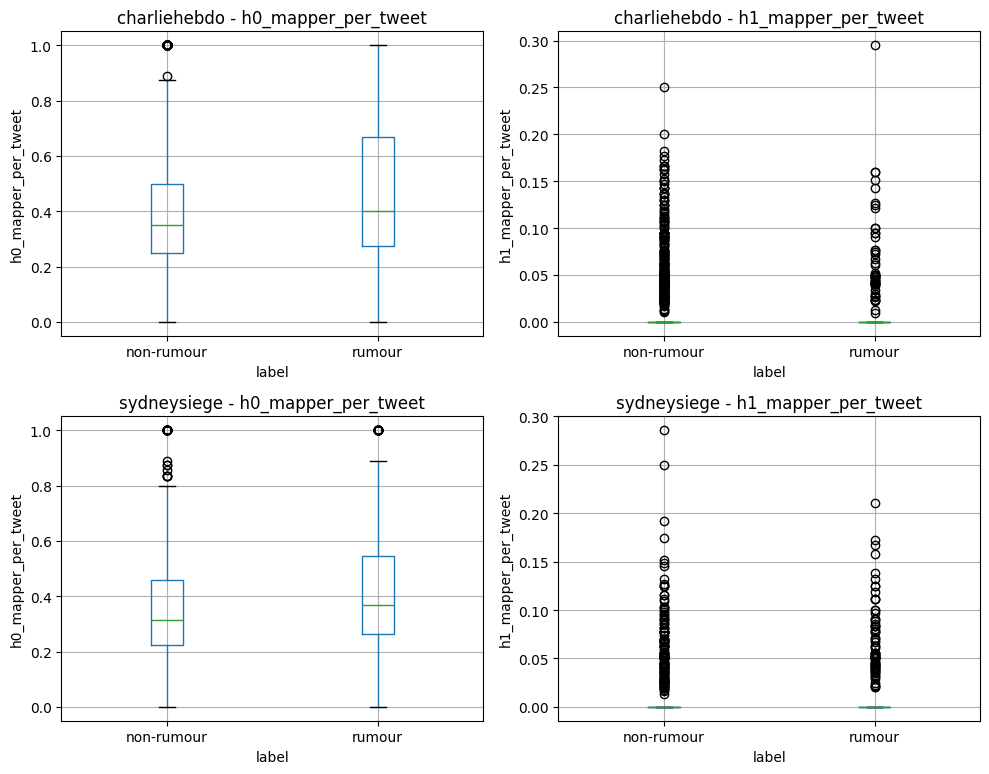

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

events = ["charliehebdo", "sydneysiege"]
features = ["h0_mapper_per_tweet", "h1_mapper_per_tweet"]

for i, event_name in enumerate(events):
    df_event = df[df["event"] == event_name].copy()

    for j, feat in enumerate(features):
        df_event.boxplot(column=feat, by="label", ax=axes[i, j])
        axes[i, j].set_title(f"{event_name} - {feat}")
        axes[i, j].set_ylabel(feat)

plt.suptitle("")
plt.tight_layout()
plt.show()

Next step: PH